# Week 8 · Day 4 — The Same Network, Now in PyTorch

Yesterday you built a two-layer network **by hand**: you wrote the forward pass, you wrote backpropagation, you wrote the weight updates, and you watched it solve the XOR that beat a single neuron.

Today we build the **exact same network** — same `2 → 4 → 1` shape, same XOR problem — in **PyTorch**, our main framework for the rest of the course. The whole point of today:

> Everything you wrote by hand yesterday, PyTorch does for you. `loss.backward()` **is** the backward pass you wrote. The optimizer **is** the `W -= lr * dW` lines you wrote.

Nothing here is new *magic*. You already know what every line does underneath. This is the well-earned rest we promised you.

**The plan:**
1. Meet the tensor (NumPy's array, with autograd built in).
2. Define the network the PyTorch way.
3. Train it — the same four moves, three of them now one-liners.
4. Watch it solve XOR, and see the same curved boundary.


<img src="images/xor-pytorch.jpg">

In [1]:
# install if needed (Colab already has it)
# !pip install torch

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(42)
print("PyTorch version:", torch.__version__)

PyTorch version: 2.8.0+cpu


---
## 1. The tensor — NumPy's array with a superpower

A **tensor** is PyTorch's version of a NumPy array. Same idea: a grid of numbers you can add, multiply, matmul. If you can use `np.array`, you can use `torch.tensor`.

The superpower: a tensor can **remember every operation done to it**, so PyTorch can later compute gradients automatically. That's called **autograd** — and it's exactly the backprop you wrote yesterday, done for you.

In [2]:
# looks just like NumPy
a = torch.tensor([1.0, 2.0, 3.0])
b = torch.tensor([4.0, 5.0, 6.0])
print("add: ", a + b)
print("dot: ", torch.dot(a, b))
print("shape:", a.shape)

# convert between numpy and torch freely
arr = np.array([1.0, 2.0, 3.0])
print("from numpy:", torch.from_numpy(arr))
print("to numpy:  ", a.numpy())

add:  tensor([5., 7., 9.])
dot:  tensor(32.)
shape: torch.Size([3])
from numpy: tensor([1., 2., 3.], dtype=torch.float64)
to numpy:   [1. 2. 3.]


### The XOR problem — same data as yesterday
The exact four points that beat a single neuron and were solved by your hand-built network.

In [3]:
# same XOR — now as tensors instead of numpy arrays
X = torch.tensor([[0,0],[0,1],[1,0],[1,1]], dtype=torch.float32)
y = torch.tensor([[0],[1],[1],[0]], dtype=torch.float32)

print("inputs X:\n", X)
print("targets y:", y.ravel())

inputs X:
 tensor([[0., 0.],
        [0., 1.],
        [1., 0.],
        [1., 1.]])
targets y: tensor([0., 1., 1., 0.])


---
## 2. Define the network

Yesterday you created `W1, b1, W2, b2` by hand and wrote the forward pass yourself. PyTorch bundles all of that into a **module**. You describe the *shape* of the network; PyTorch creates and tracks the weights for you.

Our network is unchanged: **2 inputs → 4 hidden neurons → 1 output.**

- `nn.Linear(2, 4)` is your `X @ W1 + b1` — it holds `W1` and `b1` inside.
- `nn.Sigmoid()` is your `sigmoid()`.
- `nn.Linear(4, 1)` is your `a1 @ W2 + b2` — it holds `W2` and `b2`.

The `forward` method is your forward pass, written the same way you did — just data flowing layer by layer.

<img src="images/network-pytorch.jpg">

In [4]:
class XORNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.hidden = nn.Linear(2, 4)   # inputs -> hidden  (holds W1, b1)
        self.output = nn.Linear(4, 1)   # hidden -> output  (holds W2, b2)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        a1 = self.sigmoid(self.hidden(x))   # hidden layer
        a2 = self.sigmoid(self.output(a1))  # output layer = prediction
        return a2

torch.manual_seed(42)
model = XORNet()
print(model)

XORNet(
  (hidden): Linear(in_features=2, out_features=4, bias=True)
  (output): Linear(in_features=4, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


The weights are already inside, created randomly for us — the same random start you did by hand with `np.random.randn`. Let's run the forward pass once, untrained, exactly like yesterday.

In [5]:
with torch.no_grad():                 # "just predict, don't track gradients"
    preds = model(X)

print("predictions (untrained):", preds.ravel().round(decimals=3))
print("targets:                ", y.ravel())

predictions (untrained): tensor([0.6840, 0.6950, 0.6910, 0.7010])
targets:                 tensor([0., 1., 1., 0.])


Garbage predictions from random weights — same starting point as yesterday. Now we train.

---
## 3. Train it — the same four moves

Yesterday's training loop had four moves:

1. **forward** — get predictions
2. **loss** — measure how wrong
3. **backward** — backpropagation (you wrote this by hand!)
4. **update** — nudge every weight

PyTorch keeps the *exact same four moves*. The difference: steps 3 and 4, which took you a whole notebook yesterday, are now **one line each**.

- The **loss function** (`nn.MSELoss`) is your `np.mean((a2 - y)**2)`.
- The **optimizer** (`SGD`) is your `W -= learning_rate * dW` — it does the update for every weight.
- `loss.backward()` is your entire `backward()` function — all the gradient math, computed automatically by autograd.


<img src="images/train-pytorch.jpg">

In [8]:
loss_fn = nn.MSELoss()                                    # same loss as yesterday
optimizer = torch.optim.SGD(model.parameters(), lr=0.5)  # same update rule, lr=0.5

history = []

for epoch in range(5000):
    # 1. forward
    preds = model(X)
    # 2. loss
    loss = loss_fn(preds, y)
    history.append(loss.item())

    # 3. backward  (this ONE line is your whole backward() function)
    optimizer.zero_grad()   # clear old gradients first
    loss.backward()         # autograd computes every gradient for you

    # 4. update    (this ONE line is your W -= lr * dW for every weight)
    optimizer.step()

print(f"final loss: {history[-1]:.4f}")

final loss: 0.0017


**That's the whole trick of PyTorch.** The three hardest things you built yesterday — the loss, the backward pass, the weight update — are now `loss_fn(...)`, `loss.backward()`, and `optimizer.step()`.

One new detail: `optimizer.zero_grad()`. PyTorch *adds up* gradients by default, so we clear them at the start of each step. (Yesterday you recomputed `dW1, dW2` fresh each loop, so this wasn't needed — it's the one bit of bookkeeping the framework asks of you.)

### Did it solve XOR?

In [9]:
with torch.no_grad():
    preds = model(X)
predictions = (preds > 0.5).int()

print("input     prediction   target")
for i in range(4):
    print(f"{X[i].int().tolist()}        {predictions[i][0].item()}            {int(y[i][0])}")

accuracy = (predictions == y.int()).float().mean()
print(f"\naccuracy: {accuracy.item():.0%}")

input     prediction   target
[0, 0]        0            0
[0, 1]        1            1
[1, 0]        1            1
[1, 1]        0            0

accuracy: 100%


**100% — XOR solved again!** 🎉

Same result as your hand-built network, a fraction of the code. You didn't lose any understanding — you *earned* the shortcut by building the long way first.

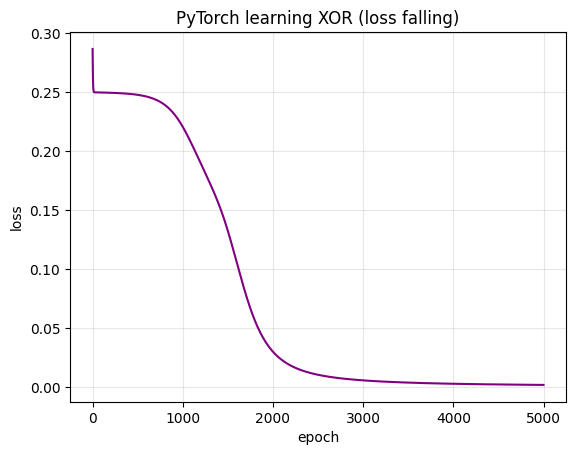

In [8]:
plt.plot(history, color="purple")
plt.xlabel("epoch"); plt.ylabel("loss")
plt.title("PyTorch learning XOR (loss falling)")
plt.grid(alpha=0.3)
plt.show()

The same **plateau-then-breakthrough** shape you saw yesterday: flat for a while, then a sudden drop as the network "gets it." Same learning dynamics — because it's the same math, just automated.

---
## 4. The curved boundary

And the same payoff: a **curved** decision boundary, the thing a single neuron could never draw.

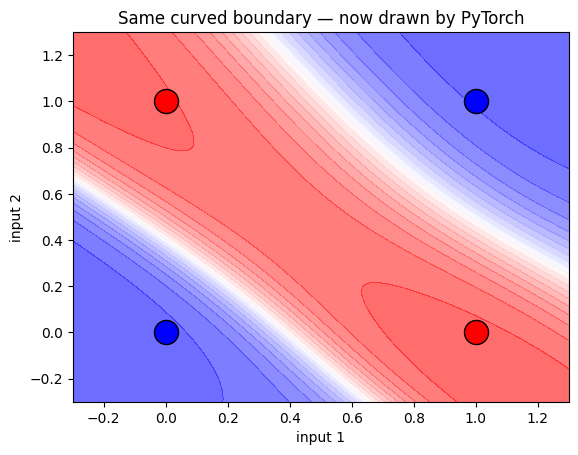

In [9]:
xx, yy = np.meshgrid(np.linspace(-0.3, 1.3, 200), np.linspace(-0.3, 1.3, 200))
grid = np.c_[xx.ravel(), yy.ravel()]

with torch.no_grad():
    grid_pred = model(torch.tensor(grid, dtype=torch.float32)).numpy()
grid_pred = grid_pred.reshape(xx.shape)

plt.contourf(xx, yy, grid_pred, levels=20, cmap="bwr", alpha=0.6)
for i in range(4):
    color = "red" if y[i] > 0.5 else "blue"
    plt.scatter(X[i,0], X[i,1], c=color, s=300, edgecolor="k", zorder=3)
plt.title("Same curved boundary — now drawn by PyTorch")
plt.xlabel("input 1"); plt.ylabel("input 2")
plt.show()

The same curve, bending to separate the red corners from the blue. Identical result, because it's the identical network — you just described it instead of hand-coding it.

---
## A cleaner way to write the same network

Once you're comfortable, small networks are often written with `nn.Sequential` — just a stack of layers, no custom class needed. This is **exactly** the same `2 → 4 → 1` network, written shorter. Good to recognize, since you'll see it everywhere.

In [10]:
torch.manual_seed(42)
model2 = nn.Sequential(
    nn.Linear(2, 4),
    nn.Sigmoid(),
    nn.Linear(4, 1),
    nn.Sigmoid()
)

# train with the identical loop
optimizer = torch.optim.SGD(model2.parameters(), lr=0.5)
for epoch in range(5000):
    loss = loss_fn(model2(X), y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

with torch.no_grad():
    acc = ((model2(X) > 0.5).int() == y.int()).float().mean()
print(f"Sequential model accuracy: {acc.item():.0%}  — same network, fewer lines")

Sequential model accuracy: 100%  — same network, fewer lines


---
## Summary

- A **tensor** is a NumPy array with **autograd** — it remembers operations so gradients come for free.
- A network is an `nn.Module`: you describe the layers (`nn.Linear`, `nn.Sigmoid`), PyTorch holds the weights.
- The training loop is the **same four moves** you already know:
  - `preds = model(X)` — forward
  - `loss = loss_fn(preds, y)` — loss
  - `loss.backward()` — **your entire backward pass, in one line**
  - `optimizer.step()` — **your entire weight update, in one line**
  - (plus `optimizer.zero_grad()` — clear old gradients each step)
- Same XOR, same 100%, same curved boundary — a fraction of the code.

You didn't skip any understanding. You built it by hand first, so now every PyTorch line maps onto something you *know*.

> **`nn.Linear` is `W @ x + b`. `loss.backward()` is backprop. `optimizer.step()` is `W -= lr * dW`.**

**Next:** we take this same tool to a *real* dataset — more inputs, more neurons, real predictions — and also peek at **TensorFlow/Keras**, the other framework you'll meet in the wild, so you can read code written in either.